# Deutsch's Algorithm

Problem: Given a black box function $f: \{0,1\} \to \{0,1\}$, determine whether the function is constant, meaning it outputs the same value regardless of the input, or balanced, meaning it outputs different values for the two different inputs. 

Classically, the solution requires 2 queries to $f$, while the quantum algorithm takes advantage of quantum superposition and interference to solve the problem in 1 query to the oracle. The algorithm measures 0 on the input qubit iff $f$ is constant, else 1.

In this notebook I build the algorithm for all four possible oracles for the one-bit $f$: the two constant functions, $f_0$ and $f_1$, outputting 0 and 1 respectively, and the two balanced functions, $f_x$ and $f_{nx}$, the identity and negation functions respectively. 

In [13]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from IPython.display import display

In [14]:
oracles = {'0': [], '1': [lambda qc: qc.x(1)], 'x': [lambda qc: qc.cx(0,1)], 'nx': [lambda qc: qc.cx(0,1), lambda qc: qc.x(1)]}
#0 - constant, outputs 0; 1 - constant, outputs 1; x - balanced, outputs input; nx - balanced, outputs NOT input
def make_deutsch_circuit(oracle):
    assert oracle in oracles
    qc = QuantumCircuit(2,1)
    qc.h(0)
    qc.x(1)
    qc.h(1) #prepares target in |-> state so oracle action appears as phase kickback on input qubit
    for operator in oracles[oracle]:
        operator(qc)
    qc.h(0)
    qc.measure(0,0)
    return qc

Deutsch Circuit for f0:


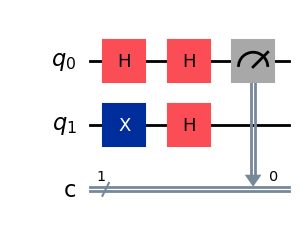

Constant

Deutsch Circuit for f1:


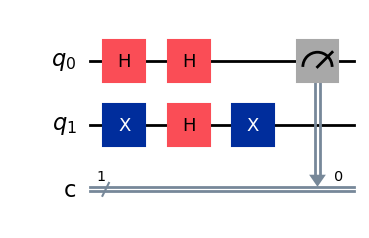

Constant

Deutsch Circuit for fx:


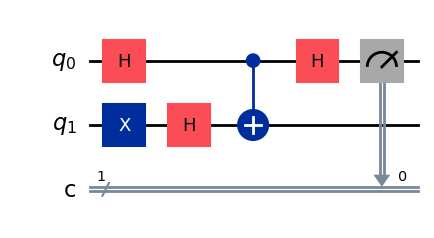

Balanced

Deutsch Circuit for fnx:


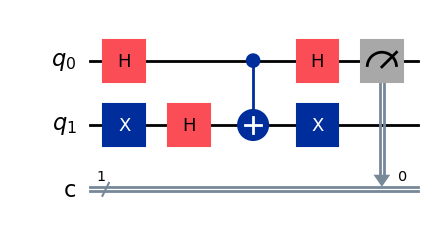

Balanced



In [15]:
for oracle in oracles:
    circuit = make_deutsch_circuit(oracle)
    print(f'Deutsch Circuit for f{oracle}:')
    display(circuit.draw('mpl'))
    sampler = StatevectorSampler(default_shots=1000)
    result = sampler.run([circuit]).result()
    counts = result[0].data.c.get_counts()
    measured_bit = int(list(counts.keys())[0]) #determinsitic - same outcome in each measurement
    if measured_bit == 0:
        print("Constant")
    else:
        print("Balanced")
    print()
